In [1]:
# ============================================================
# CELDA 1 — Setup del experimento
# ============================================================

from pathlib import Path
import csv
import sys

import matplotlib.pyplot as plt
import numpy as np

# El notebook puede estar en:
#   repo/
#       env.py
#       policy_iteration.py
#       value_iteration.py
#       experiments/
#           experiments.ipynb
#       results/
#
# Esto permite ejecutarlo tanto desde repo/ como desde repo/experiments/.
CWD = Path.cwd().resolve()

if (CWD / "env.py").exists():
    ROOT = CWD
elif (CWD.parent / "env.py").exists():
    ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "No encuentro env.py. Ejecuta el notebook desde la raíz del repo "
        "o desde la carpeta experiments/."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

from env import (
    JumpToTheGoalEnv,
    INITIAL_STATES,
    N_NON_TERMINAL,
    TERMINAL_STATE,
    R_STEP,
    R_OBSTACLE,
    R_GOAL,
)

# Importamos las implementaciones ORIGINALES únicamente para comprobar
# después que las versiones instrumentadas producen exactamente lo mismo.
from policy_iteration import policy_iteration
from value_iteration import value_iteration

In [2]:
# ------------------------------------------------------------
# Parámetros del experimento
# ------------------------------------------------------------

# Se mantiene fijo el entorno para aislar el efecto de gamma y tol.
DETERMINISTIC = True
STOCHASTIC_PROB = 0.8

# Valores a estudiar.
# Si el enunciado exige otros valores, basta con modificar estas dos listas.
GAMMAS = [0.5, 0.9, 0.99]
TOLERANCES = [1e-1, 1e-2, 1e-3, 1e-4]

# Caso representativo usado después para visualizar la evolución de V.
REFERENCE_GAMMA = 0.9
REFERENCE_TOL = 1e-3

assert REFERENCE_GAMMA in GAMMAS
assert REFERENCE_TOL in TOLERANCES

In [3]:
# ------------------------------------------------------------
# Construcción del entorno
# ------------------------------------------------------------

env = JumpToTheGoalEnv(
    render_mode=None,
    deterministic=DETERMINISTIC,
    prob=STOCHASTIC_PROB,
    r_step=R_STEP,
    r_obstacle=R_OBSTACLE,
    r_goal=R_GOAL,
)

P = env.P
nS = env.nS
nA = env.nA


# Comprobaciones básicas antes de experimentar.
assert nS == N_NON_TERMINAL + 1
assert TERMINAL_STATE == N_NON_TERMINAL
assert nA == 2

print("Configuración fija del entorno")
print("-" * 50)
print(f"Determinista: {DETERMINISTIC}")
print(f"Estados: {nS} = {N_NON_TERMINAL} no terminales + T")
print(f"Acciones: {nA}")
print(f"Estados iniciales: {INITIAL_STATES}")
print(f"r_step = {R_STEP}")
print(f"r_obstacle = {R_OBSTACLE}")
print(f"r_goal = {R_GOAL}")
print()
print(f"Gammas estudiados: {GAMMAS}")
print(f"Tolerancias estudiadas: {TOLERANCES}")

Configuración fija del entorno
--------------------------------------------------
Determinista: True
Estados: 21 = 20 no terminales + T
Acciones: 2
Estados iniciales: (0, 4, 8, 12)
r_step = -1.0
r_obstacle = -5.0
r_goal = 5.0

Gammas estudiados: [0.5, 0.9, 0.99]
Tolerancias estudiadas: [0.1, 0.01, 0.001, 0.0001]


In [4]:
# ============================================================
# CELDA 2 — Copias instrumentadas de los algoritmos
# ============================================================
#
# Estas funciones reproducen el código del repo.
# La única diferencia es que guardan:
#
#   - número de barridos/iteraciones,
#   - delta de cada barrido,
#   - delta con el que se rompe el while,
#   - evolución de V.
#
# No se modifica policy_iteration.py ni value_iteration.py.


def policy_evaluation_experiment(P, nS, nA, policy, gamma=0.9, tol=1e-3):
    V = np.zeros(nS)

    delta_history = []
    V_history = []

    while True:
        delta = 0.0

        for state in range(nS):
            old_value = V[state]
            action = int(policy[state])

            V[state] = sum(
                probability * (reward + gamma * V[next_state])
                for probability, next_state, reward, terminal
                in P[state][action]
            )

            delta = max(delta, abs(old_value - V[state]))

        # Guardamos el resultado del barrido completo.
        delta_history.append(delta)
        V_history.append(V.copy())

        if delta < tol:
            break

    metrics = {
        "sweeps": len(delta_history),
        "delta_history": np.asarray(delta_history),
        "V_history": np.asarray(V_history),
        "break_delta": delta_history[-1],
    }

    return V, metrics

In [5]:
def policy_improvement_experiment(
    P, nS, nA, value_from_policy, gamma=0.9
):
    new_policy = np.zeros(nS, dtype=int)

    for state in range(nS):
        action_values = np.zeros(nA)

        for action in range(nA):
            action_values[action] = sum(
                probability
                * (reward + gamma * value_from_policy[next_state])
                for probability, next_state, reward, terminal
                in P[state][action]
            )

        new_policy[state] = int(np.argmax(action_values))

    return new_policy

In [6]:
def policy_iteration_experiment(P, nS, nA, gamma=0.9, tol=1e-3):
    V = np.zeros(nS)
    policy = np.zeros(nS, dtype=int)

    outer_iterations = 0

    # Una evaluación de política contiene varios barridos.
    evaluation_sweeps_each = []
    evaluation_break_deltas = []

    # Guardamos V después de cada evaluación completa de política.
    # Esto permite ver cómo cambia V entre iteraciones externas de PI.
    outer_V_history = []

    while True:
        V, eval_metrics = policy_evaluation_experiment(
            P, nS, nA, policy, gamma, tol
        )

        outer_iterations += 1

        evaluation_sweeps_each.append(eval_metrics["sweeps"])
        evaluation_break_deltas.append(eval_metrics["break_delta"])
        outer_V_history.append(V.copy())

        new_policy = policy_improvement_experiment(
            P, nS, nA, V, gamma
        )

        converged = np.array_equal(policy, new_policy)
        policy = new_policy

        if converged:
            break

    metrics = {
        # Iteraciones externas evaluación -> mejora.
        "outer_iterations": outer_iterations,

        # Barridos totales empleados en todas las evaluaciones.
        # Esta será nuestra medida principal de esfuerzo.
        "evaluation_sweeps_total": int(sum(evaluation_sweeps_each)),

        "evaluation_sweeps_each": evaluation_sweeps_each,

        # Cada policy_evaluation tiene su propio while.
        "evaluation_break_deltas": evaluation_break_deltas,

        # Delta del último while que se ejecutó.
        "final_break_delta": evaluation_break_deltas[-1],

        # Un V por iteración externa de Policy Iteration.
        "V_history": np.asarray(outer_V_history),
    }

    return V, policy, metrics

In [7]:
def value_iteration_experiment(P, nS, nA, gamma=0.9, tol=1e-3):
    V = np.zeros(nS)
    policy = np.zeros(nS, dtype=int)

    delta_history = []
    V_history = []

    while True:
        delta = 0.0

        for state in range(nS):
            old_value = V[state]

            V[state] = max(
                sum(
                    probability * (reward + gamma * V[next_state])
                    for probability, next_state, reward, terminal
                    in P[state][action]
                )
                for action in range(nA)
            )

            delta = max(delta, abs(old_value - V[state]))

        delta_history.append(delta)
        V_history.append(V.copy())

        if delta < tol:
            break

    # Política greedy final, igual que en value_iteration.py.
    policy = np.array([
        max(
            range(nA),
            key=lambda action: sum(
                probability * (reward + gamma * V[next_state])
                for probability, next_state, reward, terminal
                in P[state][action]
            ),
        )
        for state in range(nS)
    ])

    metrics = {
        "sweeps": len(delta_history),
        "delta_history": np.asarray(delta_history),
        "V_history": np.asarray(V_history),
        "break_delta": delta_history[-1],
    }

    return V, policy, metrics

In [8]:
# ============================================================
# CELDA 3 — Comprobación contra el código original + experimentos
# ============================================================

# ------------------------------------------------------------
# 1. Comprobamos que instrumentar NO ha cambiado el algoritmo
# ------------------------------------------------------------

V_pi_original, policy_pi_original = policy_iteration(
    P,
    nS,
    nA,
    gamma=REFERENCE_GAMMA,
    tol=REFERENCE_TOL,
)

V_pi_exp, policy_pi_exp, _ = policy_iteration_experiment(
    P,
    nS,
    nA,
    gamma=REFERENCE_GAMMA,
    tol=REFERENCE_TOL,
)

V_vi_original, policy_vi_original = value_iteration(
    P,
    nS,
    nA,
    gamma=REFERENCE_GAMMA,
    tol=REFERENCE_TOL,
)

V_vi_exp, policy_vi_exp, _ = value_iteration_experiment(
    P,
    nS,
    nA,
    gamma=REFERENCE_GAMMA,
    tol=REFERENCE_TOL,
)


assert np.allclose(V_pi_original, V_pi_exp, atol=1e-12, rtol=0)
assert np.array_equal(policy_pi_original, policy_pi_exp)

assert np.allclose(V_vi_original, V_vi_exp, atol=1e-12, rtol=0)
assert np.array_equal(policy_vi_original, policy_vi_exp)

print("OK: las funciones instrumentadas reproducen exactamente el código original.")

OK: las funciones instrumentadas reproducen exactamente el código original.


In [9]:
# ------------------------------------------------------------
# 2. Ejecutamos todas las combinaciones gamma x tolerancia
# ------------------------------------------------------------

results = []

for gamma in GAMMAS:
    for tol in TOLERANCES:

        # ---------------- Policy Iteration ----------------
        V, policy, metrics = policy_iteration_experiment(
            P,
            nS,
            nA,
            gamma=gamma,
            tol=tol,
        )

        results.append({
            "algorithm": "Policy Iteration",
            "gamma": gamma,
            "tol": tol,
            "V": V.copy(),
            "policy": policy.copy(),

            # Número de iteraciones externas de PI.
            "outer_iterations": metrics["outer_iterations"],

            # Número total de barridos realizados por policy_evaluation.
            "sweeps": metrics["evaluation_sweeps_total"],

            "break_delta": metrics["final_break_delta"],
            "all_break_deltas": metrics["evaluation_break_deltas"],

            # En PI hay un V por iteración externa.
            "V_history": metrics["V_history"],
        })

        # ---------------- Value Iteration ----------------
        V, policy, metrics = value_iteration_experiment(
            P,
            nS,
            nA,
            gamma=gamma,
            tol=tol,
        )

        results.append({
            "algorithm": "Value Iteration",
            "gamma": gamma,
            "tol": tol,
            "V": V.copy(),
            "policy": policy.copy(),

            # No existe la misma distinción interna que en PI.
            "outer_iterations": None,

            # Un sweep = un barrido completo de Value Iteration.
            "sweeps": metrics["sweeps"],

            "break_delta": metrics["break_delta"],
            "all_break_deltas": [metrics["break_delta"]],

            # En VI hay un V por barrido.
            "V_history": metrics["V_history"],
        })


# Acceso cómodo a cualquier experimento.
results_by_key = {
    (r["algorithm"], r["gamma"], r["tol"]): r
    for r in results
}

print(f"Experimentos ejecutados: {len(results)}")

Experimentos ejecutados: 24


In [10]:
# ============================================================
# CELDA 4 — Resumen numérico y comprobaciones de convergencia
# ============================================================

np.set_printoptions(precision=6, suppress=True)


# ------------------------------------------------------------
# 1. Tabla compacta
# ------------------------------------------------------------

header = (
    f"{'Algoritmo':<18}"
    f"{'gamma':>8}"
    f"{'tol':>12}"
    f"{'outer':>8}"
    f"{'sweeps':>9}"
    f"{'delta break':>16}"
    + "".join(f"{'V(s' + str(s) + ')':>12}" for s in INITIAL_STATES)
)

print(header)
print("-" * len(header))

for r in results:
    outer = "-" if r["outer_iterations"] is None else str(r["outer_iterations"])

    values_initial = "".join(
        f"{r['V'][s]:12.5f}"
        for s in INITIAL_STATES
    )

    print(
        f"{r['algorithm']:<18}"
        f"{r['gamma']:8.2f}"
        f"{r['tol']:12.1e}"
        f"{outer:>8}"
        f"{r['sweeps']:9d}"
        f"{r['break_delta']:16.6e}"
        f"{values_initial}"
    )

Algoritmo            gamma         tol   outer   sweeps     delta break       V(s0)       V(s4)       V(s8)      V(s12)
-----------------------------------------------------------------------------------------------------------------------
Policy Iteration      0.50     1.0e-01       3       12    0.000000e+00    -1.12500    -1.56250    -1.12500    -1.56250
Value Iteration       0.50     1.0e-01       -        4    0.000000e+00    -1.12500    -1.56250    -1.12500    -1.56250
Policy Iteration      0.50     1.0e-02       3       12    0.000000e+00    -1.12500    -1.56250    -1.12500    -1.56250
Value Iteration       0.50     1.0e-02       -        4    0.000000e+00    -1.12500    -1.56250    -1.12500    -1.56250
Policy Iteration      0.50     1.0e-03       3       12    0.000000e+00    -1.12500    -1.56250    -1.12500    -1.56250
Value Iteration       0.50     1.0e-03       -        4    0.000000e+00    -1.12500    -1.56250    -1.12500    -1.56250
Policy Iteration      0.50     1.0e-04  

In [11]:
# ------------------------------------------------------------
# 2. Valores completos para el experimento de referencia
# ------------------------------------------------------------

print("\n\nValores finales para el caso de referencia")
print(
    f"gamma={REFERENCE_GAMMA}, "
    f"tol={REFERENCE_TOL}"
)
print("-" * 60)

for algorithm in ["Policy Iteration", "Value Iteration"]:
    r = results_by_key[
        (algorithm, REFERENCE_GAMMA, REFERENCE_TOL)
    ]

    print(f"\n{algorithm}")
    print("V*(s0 ... s19):")
    print(r["V"][:N_NON_TERMINAL])

    print("pi*(s0 ... s19):")
    print(r["policy"][:N_NON_TERMINAL])

    print(f"delta final de parada = {r['break_delta']:.8e}")

    if algorithm == "Policy Iteration":
        print(
            "deltas de parada de cada policy_evaluation =",
            np.asarray(r["all_break_deltas"]),
        )



Valores finales para el caso de referencia
gamma=0.9, tol=0.001
------------------------------------------------------------

Policy Iteration
V*(s0 ... s19):
[ 0.935  -5.      3.5     3.5    -0.1585  2.15    5.      5.      0.935
  0.935   3.5     3.5    -0.1585  2.15    5.     -5.5    -5.      3.5
 -5.     -5.    ]
pi*(s0 ... s19):
[1 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0]
delta final de parada = 0.00000000e+00
deltas de parada de cada policy_evaluation = [0. 0. 0.]

Value Iteration
V*(s0 ... s19):
[ 0.935  -5.      3.5     3.5    -0.1585  2.15    5.      5.      0.935
  0.935   3.5     3.5    -0.1585  2.15    5.     -5.5    -5.      3.5
 -5.     -5.    ]
pi*(s0 ... s19):
[1 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0]
delta final de parada = 0.00000000e+00


In [12]:
# ------------------------------------------------------------
# 3. Guardamos todos los resultados numéricos en CSV
# ------------------------------------------------------------

summary_path = RESULTS_DIR / "experiment_summary.csv"

fieldnames = [
    "algorithm",
    "gamma",
    "tol",
    "outer_iterations",
    "sweeps",
    "break_delta",
] + [
    f"V_s{s}" for s in range(N_NON_TERMINAL)
]

with summary_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

    for r in results:
        row = {
            "algorithm": r["algorithm"],
            "gamma": r["gamma"],
            "tol": r["tol"],
            "outer_iterations": (
                ""
                if r["outer_iterations"] is None
                else r["outer_iterations"]
            ),
            "sweeps": r["sweeps"],
            "break_delta": r["break_delta"],
        }

        for s in range(N_NON_TERMINAL):
            row[f"V_s{s}"] = r["V"][s]

        writer.writerow(row)

print(f"\nResumen guardado en: {summary_path}")


Resumen guardado en: C:\Users\jgonz\OneDrive - Universidad Pontificia Comillas\ICAI\4º\1. CUATRI\RL\PRACTICA\reinforcement-learning-lab\lab1\results\experiment_summary.csv


In [13]:
# ------------------------------------------------------------
# 4. Comprobación pedida por Álvaro:
#
# Comparamos cada tolerancia con la tolerancia más pequeña.
#
# Límite indicado:
#
#   |tol - tol_min| + tol_min
#
# Como tol_min es la menor de las dos, esto equivale a la
# tolerancia mayor.
#
# La comparación se hace con TODOS los estados, no solamente
# con los estados iniciales.
# ------------------------------------------------------------

tol_ref = min(TOLERANCES)

validation_rows = []

print("\n\nComprobación de los valores V frente a la tolerancia más pequeña")
print("-" * 90)
print(
    f"{'Algoritmo':<18}"
    f"{'gamma':>8}"
    f"{'tol':>12}"
    f"{'max |ΔV|':>16}"
    f"{'límite':>16}"
    f"{'OK':>8}"
)

for algorithm in ["Policy Iteration", "Value Iteration"]:
    for gamma in GAMMAS:

        V_ref = results_by_key[
            (algorithm, gamma, tol_ref)
        ]["V"]

        for tol in sorted(TOLERANCES, reverse=True):

            V_current = results_by_key[
                (algorithm, gamma, tol)
            ]["V"]

            max_difference = np.max(
                np.abs(
                    V_current[:N_NON_TERMINAL]
                    - V_ref[:N_NON_TERMINAL]
                )
            )

            allowed_difference = (
                abs(tol - tol_ref) + min(tol, tol_ref)
            )

            ok = max_difference <= allowed_difference + 1e-12

            validation_rows.append({
                "algorithm": algorithm,
                "gamma": gamma,
                "tol": tol,
                "reference_tol": tol_ref,
                "max_V_difference": max_difference,
                "allowed_difference": allowed_difference,
                "ok": ok,
            })

            print(
                f"{algorithm:<18}"
                f"{gamma:8.2f}"
                f"{tol:12.1e}"
                f"{max_difference:16.6e}"
                f"{allowed_difference:16.6e}"
                f"{str(ok):>8}"
            )


validation_path = RESULTS_DIR / "tolerance_validation.csv"

with validation_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "algorithm",
            "gamma",
            "tol",
            "reference_tol",
            "max_V_difference",
            "allowed_difference",
            "ok",
        ],
    )
    writer.writeheader()
    writer.writerows(validation_rows)

print(f"\nValidación guardada en: {validation_path}")



Comprobación de los valores V frente a la tolerancia más pequeña
------------------------------------------------------------------------------------------
Algoritmo            gamma         tol        max |ΔV|          límite      OK
Policy Iteration      0.50     1.0e-01    0.000000e+00    1.000000e-01    True
Policy Iteration      0.50     1.0e-02    0.000000e+00    1.000000e-02    True
Policy Iteration      0.50     1.0e-03    0.000000e+00    1.000000e-03    True
Policy Iteration      0.50     1.0e-04    0.000000e+00    1.000000e-04    True
Policy Iteration      0.90     1.0e-01    0.000000e+00    1.000000e-01    True
Policy Iteration      0.90     1.0e-02    0.000000e+00    1.000000e-02    True
Policy Iteration      0.90     1.0e-03    0.000000e+00    1.000000e-03    True
Policy Iteration      0.90     1.0e-04    0.000000e+00    1.000000e-04    True
Policy Iteration      0.99     1.0e-01    0.000000e+00    1.000000e-01    True
Policy Iteration      0.99     1.0e-02    0.000000e+

In [14]:
# ------------------------------------------------------------
# 5. Comprobación adicional:
#    Policy Iteration y Value Iteration deberían llegar a los
#    mismos valores óptimos salvo la aproximación numérica.
#
# No exigimos que las políticas sean idénticas porque pueden
# existir empates entre acciones con el mismo valor.
# ------------------------------------------------------------

print("\n\nComparación PI vs VI usando la tolerancia más pequeña")
print("-" * 70)

for gamma in GAMMAS:
    pi = results_by_key[
        ("Policy Iteration", gamma, tol_ref)
    ]

    vi = results_by_key[
        ("Value Iteration", gamma, tol_ref)
    ]

    max_difference = np.max(
        np.abs(
            pi["V"][:N_NON_TERMINAL]
            - vi["V"][:N_NON_TERMINAL]
        )
    )

    different_actions = np.sum(
        pi["policy"][:N_NON_TERMINAL]
        != vi["policy"][:N_NON_TERMINAL]
    )

    print(
        f"gamma={gamma:.2f} | "
        f"max |V_PI - V_VI| = {max_difference:.6e} | "
        f"acciones distintas = {different_actions}"
    )



Comparación PI vs VI usando la tolerancia más pequeña
----------------------------------------------------------------------
gamma=0.50 | max |V_PI - V_VI| = 0.000000e+00 | acciones distintas = 0
gamma=0.90 | max |V_PI - V_VI| = 0.000000e+00 | acciones distintas = 0
gamma=0.99 | max |V_PI - V_VI| = 0.000000e+00 | acciones distintas = 0


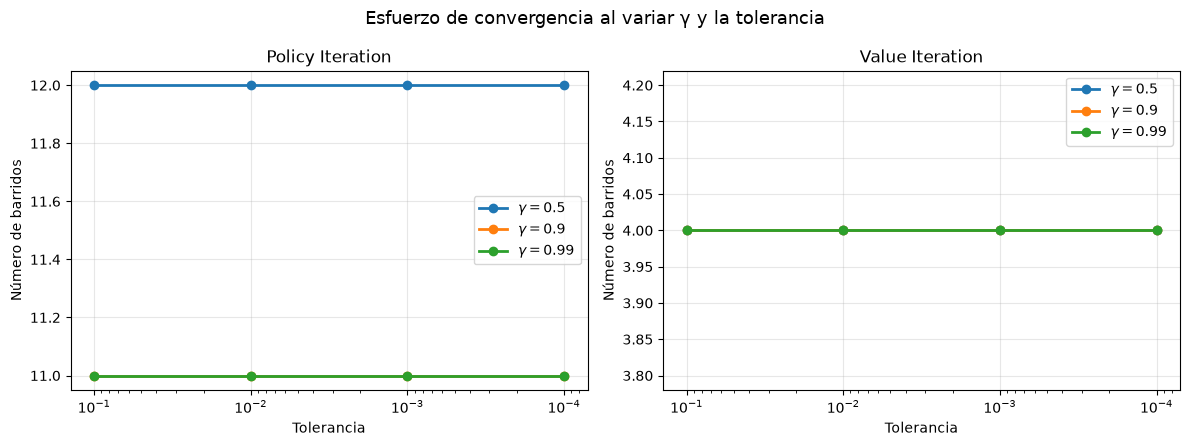

Guardado: C:\Users\jgonz\OneDrive - Universidad Pontificia Comillas\ICAI\4º\1. CUATRI\RL\PRACTICA\reinforcement-learning-lab\lab1\results\01_iterations_vs_tolerance.png


In [15]:
# ============================================================
# CELDA 5 — Gráficos principales
# ============================================================
#
# Solo dos figuras aquí:
#
# 1. Número de barridos necesarios.
# 2. Diferencia en V respecto a la tolerancia más pequeña.
#
# No usamos tiempo de ejecución porque no es una medida fiable
# para estos experimentos tan pequeños.


# ------------------------------------------------------------
# FIGURA 1 — Barridos hasta convergencia
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    sharey=False,
)

for ax, algorithm in zip(
    axes,
    ["Policy Iteration", "Value Iteration"],
):
    for gamma in GAMMAS:

        x = sorted(TOLERANCES)
        y = [
            results_by_key[
                (algorithm, gamma, tol)
            ]["sweeps"]
            for tol in x
        ]

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=fr"$\gamma={gamma}$",
        )

    ax.set_xscale("log")
    ax.invert_xaxis()

    ax.set_title(algorithm)
    ax.set_xlabel("Tolerancia")
    ax.set_ylabel("Número de barridos")
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle(
    "Esfuerzo de convergencia al variar γ y la tolerancia",
    fontsize=13,
)

fig.tight_layout()

path = RESULTS_DIR / "01_iterations_vs_tolerance.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Guardado: {path}")

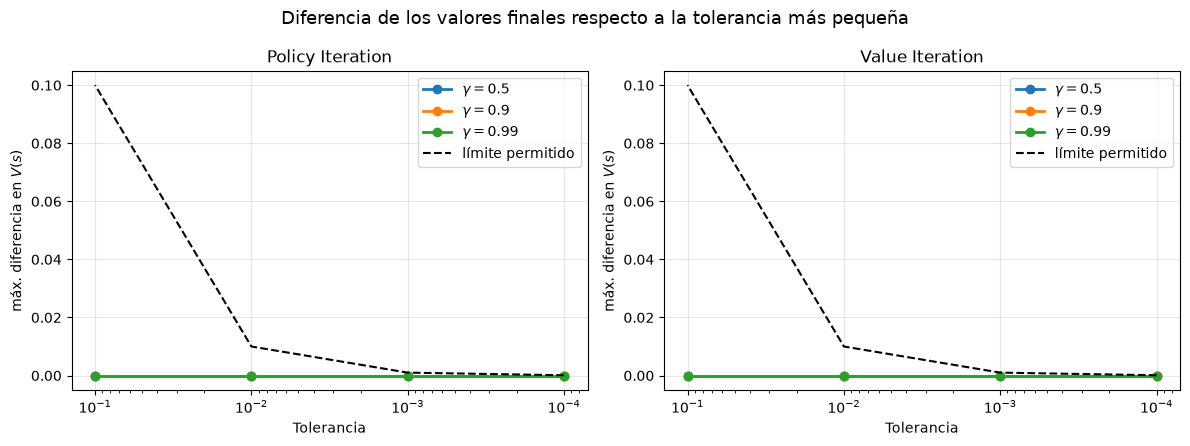

Guardado: C:\Users\jgonz\OneDrive - Universidad Pontificia Comillas\ICAI\4º\1. CUATRI\RL\PRACTICA\reinforcement-learning-lab\lab1\results\02_value_difference_vs_tolerance.png


In [16]:
# ------------------------------------------------------------
# FIGURA 2 — Diferencia de V respecto a tol mínima
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

for ax, algorithm in zip(
    axes,
    ["Policy Iteration", "Value Iteration"],
):

    for gamma in GAMMAS:

        x = sorted(TOLERANCES)

        y = []

        V_ref = results_by_key[
            (algorithm, gamma, tol_ref)
        ]["V"]

        for tol in x:
            V = results_by_key[
                (algorithm, gamma, tol)
            ]["V"]

            y.append(
                np.max(
                    np.abs(
                        V[:N_NON_TERMINAL]
                        - V_ref[:N_NON_TERMINAL]
                    )
                )
            )

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=fr"$\gamma={gamma}$",
        )

    # Según el criterio indicado por el profesor:
    # |tol - tol_min| + tol_min.
    allowed = [
        abs(tol - tol_ref) + min(tol, tol_ref)
        for tol in sorted(TOLERANCES)
    ]

    ax.plot(
        sorted(TOLERANCES),
        allowed,
        "k--",
        linewidth=1.5,
        label="límite permitido",
    )

    ax.set_xscale("log")
    ax.invert_xaxis()

    ax.set_title(algorithm)
    ax.set_xlabel("Tolerancia")
    ax.set_ylabel(r"máx. diferencia en $V(s)$")
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle(
    "Diferencia de los valores finales respecto a la tolerancia más pequeña",
    fontsize=13,
)

fig.tight_layout()

path = RESULTS_DIR / "02_value_difference_vs_tolerance.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Guardado: {path}")

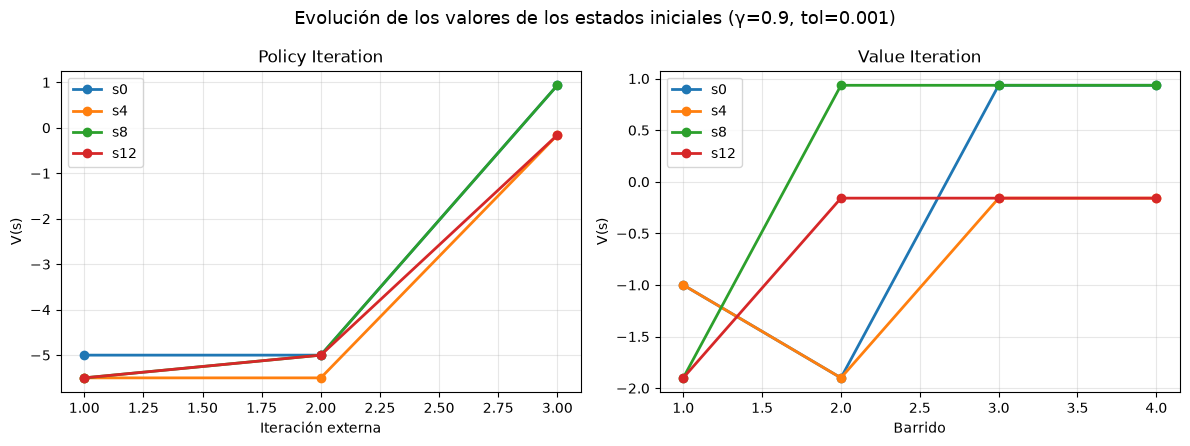

Guardado: C:\Users\jgonz\OneDrive - Universidad Pontificia Comillas\ICAI\4º\1. CUATRI\RL\PRACTICA\reinforcement-learning-lab\lab1\results\03_value_evolution.png

Archivos generados en results/:
 - 01_iterations_vs_tolerance.png
 - 02_value_difference_vs_tolerance.png
 - 03_value_evolution.png
 - experiment_summary.csv
 - tolerance_validation.csv


In [17]:
# ============================================================
# CELDA 6 — Evolución de V durante un experimento representativo
# ============================================================
#
# Tercera y última figura.
#
# Se muestran solamente los cuatro estados iniciales para evitar
# un gráfico con 20 curvas difícil de interpretar.


pi_ref = results_by_key[
    ("Policy Iteration", REFERENCE_GAMMA, REFERENCE_TOL)
]

vi_ref = results_by_key[
    ("Value Iteration", REFERENCE_GAMMA, REFERENCE_TOL)
]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

# ------------------------------------------------------------
# Policy Iteration
# ------------------------------------------------------------

V_history_pi = pi_ref["V_history"]

x_pi = np.arange(1, len(V_history_pi) + 1)

for state in INITIAL_STATES:
    axes[0].plot(
        x_pi,
        V_history_pi[:, state],
        marker="o",
        linewidth=2,
        label=f"s{state}",
    )

axes[0].set_title("Policy Iteration")
axes[0].set_xlabel("Iteración externa")
axes[0].set_ylabel("V(s)")
axes[0].grid(alpha=0.3)
axes[0].legend()

# ------------------------------------------------------------
# Value Iteration
# ------------------------------------------------------------

V_history_vi = vi_ref["V_history"]

x_vi = np.arange(1, len(V_history_vi) + 1)

for state in INITIAL_STATES:
    axes[1].plot(
        x_vi,
        V_history_vi[:, state],
        marker="o",
        linewidth=2,
        label=f"s{state}",
    )

axes[1].set_title("Value Iteration")
axes[1].set_xlabel("Barrido")
axes[1].set_ylabel("V(s)")
axes[1].grid(alpha=0.3)
axes[1].legend()


fig.suptitle(
    (
        "Evolución de los valores de los estados iniciales "
        f"(γ={REFERENCE_GAMMA}, tol={REFERENCE_TOL})"
    ),
    fontsize=13,
)

fig.tight_layout()

path = RESULTS_DIR / "03_value_evolution.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Guardado: {path}")


print("\nArchivos generados en results/:")
for p in sorted(RESULTS_DIR.iterdir()):
    if p.suffix in {".png", ".csv"}:
        print(" -", p.name)


env.close()